# Decision Trees

In [23]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, load_wine
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

import Partitioner as part

# Fix the random seed for reproducibility
# !! Important !! : do not change this
seed = 1234
np.random.seed(seed)  

In [2]:
# Load dataset
X_tr, X_val, X_te, y_tr, y_val, y_te = part.getDefaultWineSets()

## Get Dataset Context

In [17]:
# Get Dataset Context
print(f"Number of samples: {X_tr.shape[0] + X_val.shape[0] + X_te.shape[0]}")
print(f"Features per sample: {X_tr.shape[1]}")

print(y_tr[:100])

Number of samples: 6497
Features per sample: 12
[6 7 5 6 7 5 9 7 6 6 6 7 6 6 5 6 6 5 5 5 6 6 5 5 5 7 4 6 6 6 6 6 7 6 6 6 6
 7 4 6 7 5 5 6 6 5 4 6 6 5 7 5 6 5 6 6 5 6 6 6 5 6 5 6 4 8 6 4 7 6 6 6 5 3
 7 5 5 6 5 6 5 7 7 6 6 7 5 6 5 7 5 5 6 6 5 6 5 6 6 8]


Training error: 0.0
Validation error: 0.40692307692307694
Root feature index: 11
Root split threshold: 10.483333110809326


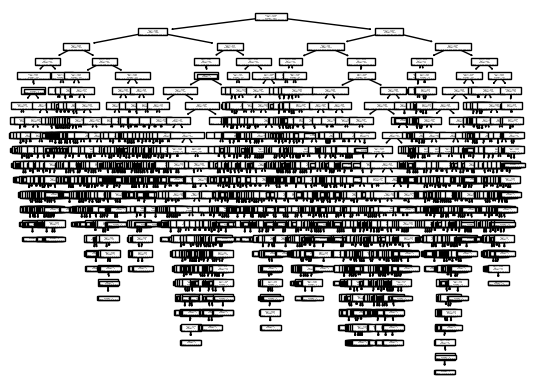

In [ ]:
# Decision tree classifier with default settings
model = DecisionTreeClassifier(random_state=seed)

model.fit(X_tr, y_tr)
err_tr = 1 - accuracy_score(y_tr, model.predict(X_tr))
err_val = 1 - accuracy_score(y_val, model.predict(X_val))

print(f"Training error: {err_tr}")
print(f"Validation error: {err_val}")

plot_tree(model)

print(f"Root feature index: {model.tree_.feature[0]}")
print(f"Root split threshold: {model.tree_.threshold[0]}")

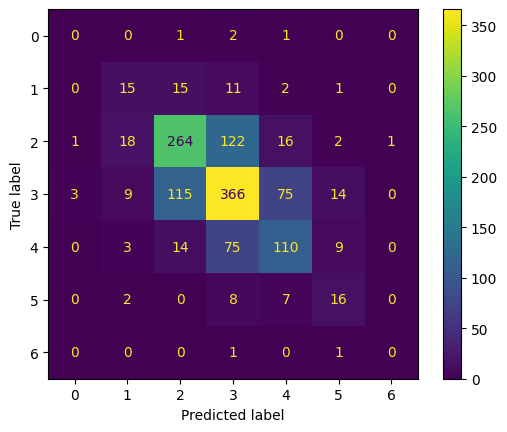

In [21]:
cm = confusion_matrix(y_val, model.predict(X_val))
sklearn_disp = ConfusionMatrixDisplay(confusion_matrix = cm)
sklearn_disp.plot();

#### Considering the values in the generated confusion matrix for a decision tree classifier with default sklearn settings, it appears that the mistakes made by the decision tree are generally small, with incorrectly predicted labels often being off by only one or two ranks. Since wine quality can be considered more of a subjective classifier, it may be within reason to group rankings that are close together into a single rank. This could be done by partitioning into low, medium, and high-quality labels

Training error: 0.0
Validation error: 0.33307692307692305


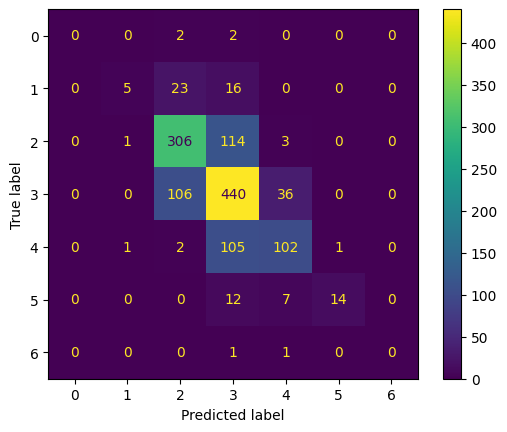

In [27]:
# Random forest classifier with default settings
model = RandomForestClassifier(random_state=seed)

model.fit(X_tr, y_tr)
err_tr = 1 - accuracy_score(y_tr, model.predict(X_tr))
err_val = 1 - accuracy_score(y_val, model.predict(X_val))

print(f"Training error: {err_tr}")
print(f"Validation error: {err_val}")

cm = confusion_matrix(y_val, model.predict(X_val))
sklearn_disp = ConfusionMatrixDisplay(confusion_matrix = cm)
sklearn_disp.plot();

Training error: 0.1634590710803182
Validation error: 0.38


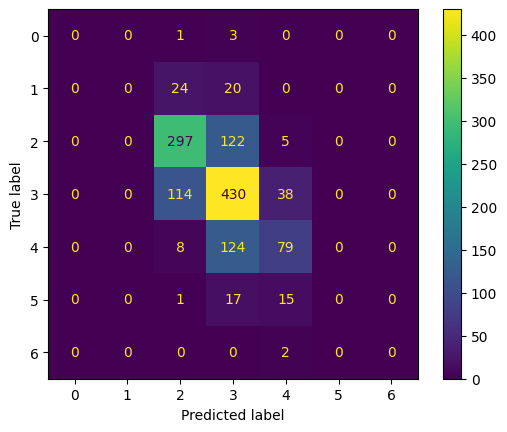

In [ ]:
# Decision tree classifier with default settings
model = RandomForestClassifier(min_samples_leaf=[k for k in np.arange(1, 16, 1)], random_state=seed)

model.fit(X_tr, y_tr)
err_tr = 1 - accuracy_score(y_tr, model.predict(X_tr))
err_val = 1 - accuracy_score(y_val, model.predict(X_val))

print(f"Training error: {err_tr}")
print(f"Validation error: {err_val}")

cm = confusion_matrix(y_val, model.predict(X_val))
sklearn_disp = ConfusionMatrixDisplay(confusion_matrix = cm)
sklearn_disp.plot();

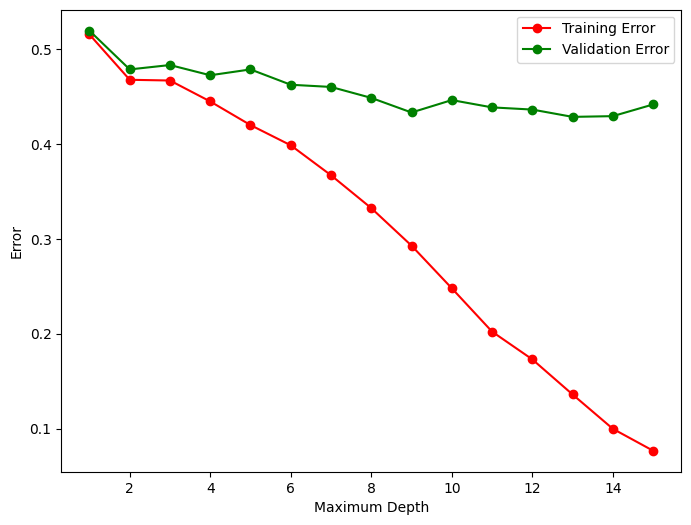

In [5]:
_, axes = plt.subplots(1, figsize=(8, 6))

max_depth = np.arange(1, 16, 1)
err_tr = np.zeros_like(max_depth, dtype=float)
err_val = np.zeros_like(max_depth, dtype=float)

for i, depth in enumerate(max_depth):
    model = DecisionTreeClassifier(max_depth=depth, random_state=seed)

    model.fit(X_tr, y_tr)
    err_tr[i] = 1 - accuracy_score(y_tr, model.predict(X_tr))
    err_val[i] = 1 - accuracy_score(y_val, model.predict(X_val))

axes.plot(max_depth, err_tr, marker='o', c='red', label="Training Error")
axes.plot(max_depth, err_val, marker='o', c='green', label="Validation Error")
axes.set_xlabel("Maximum Depth")
axes.set_ylabel("Error")
axes.legend();

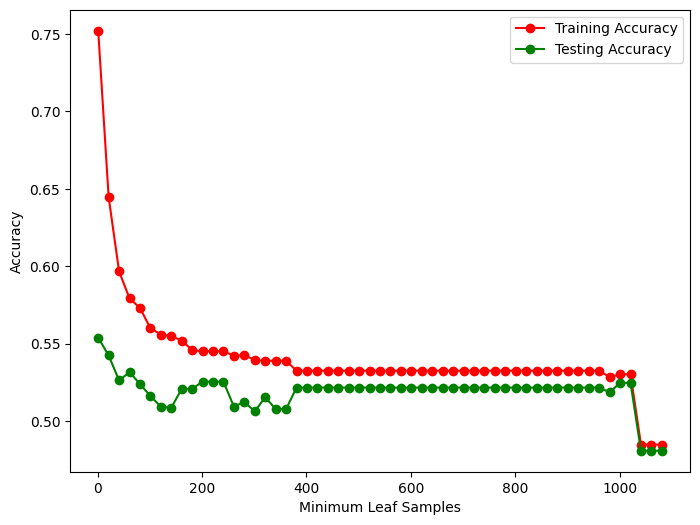

In [15]:
_, axes = plt.subplots(1, figsize=(8, 6))

min_samples_leaf = np.arange(1, 1101, 20)
err_tr = np.zeros_like(min_samples_leaf, dtype=float)
err_val = np.zeros_like(min_samples_leaf, dtype=float)

for i, min_samples in enumerate(min_samples_leaf):
    model = DecisionTreeClassifier(min_samples_leaf=min_samples, max_depth=10, random_state=seed)

    model.fit(X_tr, y_tr)
    err_tr[i] = accuracy_score(y_tr, model.predict(X_tr))
    err_val[i] = accuracy_score(y_val, model.predict(X_val))

axes.plot(min_samples_leaf, err_tr, marker='o', c='red', label="Training Accuracy")
axes.plot(min_samples_leaf, err_val, marker='o', c='green', label="Testing Accuracy")
axes.set_xlabel("Minimum Leaf Samples")
axes.set_ylabel("Accuracy")
axes.legend();

***

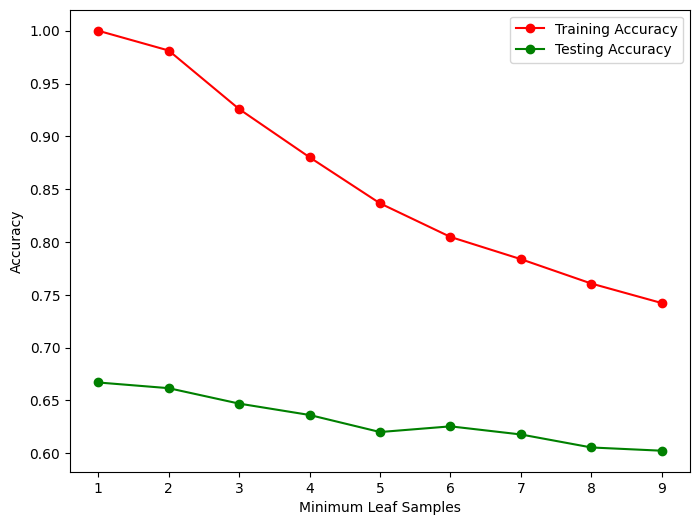

In [31]:
_, axes = plt.subplots(1, figsize=(8, 6))

min_samples_leaf = np.arange(1, 10, 1)
err_tr = np.zeros_like(min_samples_leaf, dtype=float)
err_val = np.zeros_like(min_samples_leaf, dtype=float)

for i, min_samples in enumerate(min_samples_leaf):
    model = RandomForestClassifier(min_samples_leaf=min_samples, random_state=seed)

    model.fit(X_tr, y_tr)
    err_tr[i] = accuracy_score(y_tr, model.predict(X_tr))
    err_val[i] = accuracy_score(y_val, model.predict(X_val))

axes.plot(min_samples_leaf, err_tr, marker='o', c='red', label="Training Accuracy")
axes.plot(min_samples_leaf, err_val, marker='o', c='green', label="Testing Accuracy")
axes.set_xlabel("Minimum Leaf Samples")
axes.set_ylabel("Accuracy")
axes.legend();

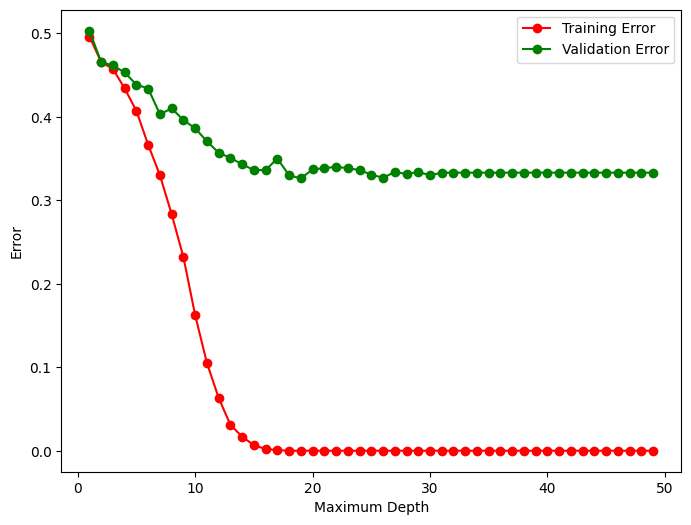

In [32]:
_, axes = plt.subplots(1, figsize=(8, 6))

max_depth = np.arange(1, 50, 1)
err_tr = np.zeros_like(max_depth, dtype=float)
err_val = np.zeros_like(max_depth, dtype=float)

for i, depth in enumerate(max_depth):
    model = RandomForestClassifier(max_depth=depth, random_state=seed)

    model.fit(X_tr, y_tr)
    err_tr[i] = 1 - accuracy_score(y_tr, model.predict(X_tr))
    err_val[i] = 1 - accuracy_score(y_val, model.predict(X_val))

axes.plot(max_depth, err_tr, marker='o', c='red', label="Training Error")
axes.plot(max_depth, err_val, marker='o', c='green', label="Validation Error")
axes.set_xlabel("Maximum Depth")
axes.set_ylabel("Error")
axes.legend();

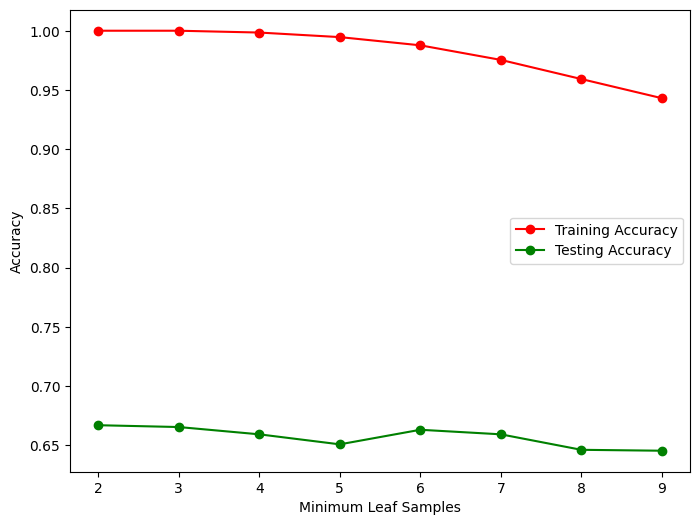

In [34]:
_, axes = plt.subplots(1, figsize=(8, 6))

min_samples_split = np.arange(2, 10, 1)
err_tr = np.zeros_like(min_samples_split, dtype=float)
err_val = np.zeros_like(min_samples_split, dtype=float)

for i, min_samples in enumerate(min_samples_split):
    model = RandomForestClassifier(min_samples_split=min_samples, random_state=seed)

    model.fit(X_tr, y_tr)
    err_tr[i] = accuracy_score(y_tr, model.predict(X_tr))
    err_val[i] = accuracy_score(y_val, model.predict(X_val))

axes.plot(min_samples_split, err_tr, marker='o', c='red', label="Training Accuracy")
axes.plot(min_samples_split, err_val, marker='o', c='green', label="Testing Accuracy")
axes.set_xlabel("Minimum Leaf Samples")
axes.set_ylabel("Accuracy")
axes.legend();

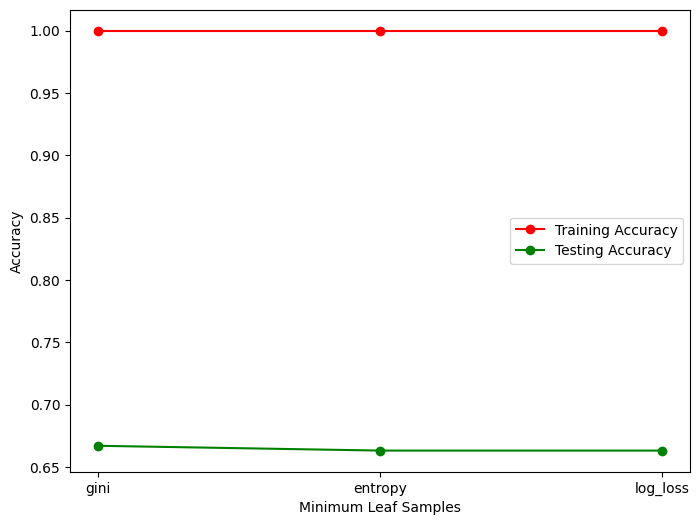

In [36]:
_, axes = plt.subplots(1, figsize=(8, 6))

score = ["gini", "entropy", "log_loss"]
err_tr = np.zeros_like(score, dtype=float)
err_val = np.zeros_like(score, dtype=float)

for i, func in enumerate(score):
    model = RandomForestClassifier(criterion=func, random_state=seed)

    model.fit(X_tr, y_tr)
    err_tr[i] = accuracy_score(y_tr, model.predict(X_tr))
    err_val[i] = accuracy_score(y_val, model.predict(X_val))

axes.plot(score, err_tr, marker='o', c='red', label="Training Accuracy")
axes.plot(score, err_val, marker='o', c='green', label="Testing Accuracy")
axes.set_xlabel("Minimum Leaf Samples")
axes.set_ylabel("Accuracy")
axes.legend();

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    "max_depth": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, None],
    "min_samples_split": [1, 2, 3, 6],
    "min_samples_leaf": [1, 2, 3, 5, 6, 7],
    "criterion": ["gini", "entropy", "log_loss"]
}

forest_grid = GridSearchCV(
    RandomForestClassifier(random_state=seed),
    params,
    cv=5,
    scoring="accuracy"
)
 
tree_grid = GridSearchCV(
    RandomForestClassifier(random_state=seed),
    params,
    cv=5,
    scoring="accuracy"
)

forest_grid.fit(X_tr, y_tr)
tree_grid.fit(X_tr, y_tr)

forest_err_tr = 1 - accuracy_score(y_tr, forest_grid.predict(X_tr))
forest_err_val = 1 - accuracy_score(y_val, forest_grid.predict(X_val))
tree_err_tr = 1 - accuracy_score(y_tr, tree_grid.predict(X_tr))
tree_err_val = 1 - accuracy_score(y_val, tree_grid.predict(X_val))

print(f"Forest training error: {forest_err_tr}")
print(f"Forest validation error: {forest_err_tr}")
print(f"Tree training error: {tree_err_tr}")
print(f"Tree validation error: {tree_err_val}")


plot_tree(model)
print("TREE EXCLUSIVE:")
print(f"Root feature index: {model.tree_.feature[0]}")
print(f"Root split threshold: {model.tree_.threshold[0]}")